In [2]:
import torch.nn as nn
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
from utils import *
from torch.utils.data import DataLoader, Subset
from models import *
import random
from collections import Counter
from collections import OrderedDict
import seaborn as sns
import copy
device = "cuda"

In [66]:
# Study2. train to maturity
# Compare the model1 (mali cos trained), and Label flipping (LP) attacks L2 to the model0
 
epochs = 12
global attack 
attack = "untargeted" #"backdoor", "tlp", "ut"
model_name = "ConvNet" # "resnet8", "ConvNet"
num_classes = 10
dataset ="fmnist"
k = 0.05
batch_size =32

In [67]:
def cos_dist(w1, w2, eps=1e-9):
    """Compute cosine distance between two flattened weight tensors"""
    w1_flat = torch.cat([p.view(-1) for p in w1])
    w2_flat = torch.cat([p.view(-1) for p in w2])
    
    # Cosine similarity computation
    cosine_similarity = torch.dot(w1_flat, w2_flat) / (torch.norm(w1_flat) * torch.norm(w2_flat) + eps)
    
    # Return cosine distance
    return 1 - cosine_similarity


def get_delta_cos(model1, model2, model0_sd):
    cos = nn.CosineSimilarity(dim=0, eps=1e-9)
    flat_model0 = flat_dict(model0_sd)
    flat_model1 = flat_dict(model1.state_dict())
    flat_model2 = flat_dict(model2.state_dict())
    
    delta = torch.abs(flat_model1 - flat_model2)
    org_cos = cos((flat_model1 - flat_model0), (flat_model2 - flat_model0))
    return delta, 1-org_cos.item()

def model_eval(model, test_loader, attack):
    acc = eval_op_ensemble([model], test_loader)
    if attack == "tlp":
        asr = eval_op_ensemble_tr_lf_attack([model], test_loader)
    elif attack == "backdoor":
        asr = eval_op_ensemble_attack([model], test_loader)
    elif attack == "untargeted":
        asr = None
    return list(acc.values())[0], list(asr.values())[0]


def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}

def get_subset_dataloader(dataset, k, batch_size=32, shuffle=True):
    """
    Randomly selects k of the dataset and returns a DataLoader.
    
    Args:
        dataset (Dataset): The dataset to sample from.
        k (float): Percentage of the dataset to use (0-1).
        batch_size (int): Number of samples per batch.
        shuffle (bool): Whether to shuffle the DataLoader.

    Returns:
        DataLoader: DataLoader with the selected subset.
    """
    num_samples = int(len(dataset) * k)
    indices = torch.randperm(len(dataset))[:num_samples]
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle)

In [68]:
# Define transformation (convert images to tensors and normalize)
transform_img = T.Compose([
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize the image with mean and std
])

if dataset == "fmnist":
    train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_img)
    test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_img)
elif dataset == "cifar10":
    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_img)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_img)
    

sub_train_loader = get_subset_dataloader(train_data, k, batch_size, shuffle=True)
train_loader = DataLoader(train_data, batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size, shuffle=False)

In [69]:
model_fn = partial(models.get_model(model_name)[0], num_classes=num_classes, dataset=dataset)
# created models 
model0 = model_fn().to(device) # orginal model
model1 = model_fn().to(device) # train with clean data

model0_sd = {k: v.clone().detach() for k, v in model0.state_dict().items()}
model1.load_state_dict(model0_sd)

optimizer0 = optim.SGD(model0.parameters(), lr=0.0001)
optimizer1 = optim.SGD(model1.parameters(), lr=0.0001)

In [7]:
def model_validation(model, validation_dataloader):
    model.eval()  # Set the model to evaluation mode

    # Initialize variables for loss and accuracy
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0

    # Define your loss function
    criterion = torch.nn.CrossEntropyLoss()  # Change if using a different loss

    # Loop through the DataLoader
    with torch.no_grad():  # Disable gradient calculation for evaluation
        for inputs, labels in validation_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Forward pass
            outputs = model(inputs)
            
            # Calculate the loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_predictions += labels.size(0)

    # Calculate average loss and accuracy
    avg_loss = total_loss / len(validation_dataloader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

In [8]:
def get_model_diff(model0, model1):
    """
    Compares two models layer by layer and returns the difference in parameters.

    Args:
    - model0 (nn.Module): The first model to compare.
    - model1 (nn.Module): The second model to compare.

    Returns:
    - model1 - model0
    - dict: A dictionary containing the differences between layers.
    """
    model_diff = {}

    # Check if the models have the same architecture
    if len(list(model0.parameters())) != len(list(model1.parameters())):
        raise ValueError("Models have different number of parameters or layers")

    # Iterate through each layer's parameters
    for (name0, param0), (name1, param1) in zip(model0.named_parameters(), model1.named_parameters()):
        if name0 != name1:
            raise ValueError(f"Layer names mismatch: {name0} != {name1}")
        
        # Calculate the difference between the two layers' parameters
        diff = param1 - param0

        # Store the difference in the dictionary
        model_diff[name0] = diff

    return model_diff


In [9]:
# train model1 keep logging of gradient
training_loss, samples = 0.0, 0
val_loss_list = []
val_acc_list = []
grad_list = []
last_model = copy.deepcopy(model0)
for ep in range(epochs):
    last_model = copy.deepcopy(model1)
    # training
    for it, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer1.zero_grad()
        loss = nn.CrossEntropyLoss()(model1(x), y)
        training_loss += loss.item() * y.shape[0]
        samples += y.shape[0]
        loss.backward()
        optimizer1.step()
    
    # validation
    val_loss, val_acc = model_validation(model1, test_loader)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)
    print(f"ep{ep}, val_loss:{val_loss}, val_acc:{val_acc}")
    
    # save the graident
    grad = get_model_diff(last_model, model1)
    grad_list.append(grad)

ep0, val_loss:1.055187409297346, val_acc:0.7376
ep1, val_loss:0.8272069325081457, val_acc:0.7543
ep2, val_loss:0.7317263156461259, val_acc:0.7684
ep3, val_loss:0.6767867175154031, val_acc:0.7794
ep4, val_loss:0.6395259265320751, val_acc:0.787
ep5, val_loss:0.6116427183151245, val_acc:0.7926
ep6, val_loss:0.5894056792838124, val_acc:0.7985
ep7, val_loss:0.5708563116411812, val_acc:0.8027
ep8, val_loss:0.5548985679500019, val_acc:0.808
ep9, val_loss:0.5408232676716277, val_acc:0.8135
ep10, val_loss:0.52819670789158, val_acc:0.8179
ep11, val_loss:0.5167205612689924, val_acc:0.8222


In [109]:
def weighted_avg_budget_cos(a: torch.Tensor, b: torch.Tensor, budget: float):
    """
    Compute tensor c as a weighted average of a and b such that:
        c = t * a + (1 - t) * b
    where t is in [0,1] and ensures that 1 - cos(a, c) <= budget.

    Uses binary search to find the optimal t.

    :param a: Tensor
    :param b: Tensor
    :param budget: Float, constraint on 1 - cosine similarity
    :return: Tuple (c, t)
    """
    a = a.detach().clone()
    b = b.detach().clone()
    
    def cosine_similarity(x, y):
        return torch.nn.functional.cosine_similarity(x.flatten(), y.flatten(), dim=0)
    
    left, right = 0.0, 1.0
    best_t = right
    while right - left > 1e-3:
        # print("left,right", left, right)
        mid = (left + right) / 2
        c = mid * a + (1 - mid) * b
        cos_d = 1 - cosine_similarity(a, c)

        if cos_d <= budget:
            best_t = mid  # Store valid t
            right = mid  # Try a smaller t
        else:
            left = mid  # Increase t
    
    c = best_t * a + (1 - best_t) * b
    cos_d = 1 - cosine_similarity(a, c)
    return c, best_t*100, cos_d

In [110]:
def train_rev_w_cos(model, loader, optimizer, scheduler, epochs, model0, model1, beta, budget):    
    model.train()
    # model.parameters need to use 
    flat_grad_model0 = flat_dict(filter_trainable_state_dict(model0))
    flat_grad_model1 = flat_dict(filter_trainable_state_dict(model1))
    grad_ben = (flat_grad_model1 - flat_grad_model0).to(device)
    
    losses = []
    running_loss, samples = 0.0, 0
    print(f"data length {len(loader) * loader.batch_size}: batches {len(loader)}, batch_size {loader.batch_size}")
    
    for ep in range(epochs):
        for it, (x, y) in enumerate(loader):
            if it % 2 == 0:
                losses.append(round(eval_epoch(model, loader), 2))
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss_ce = nn.CrossEntropyLoss(reduction="mean")(model(x), y)

            # in the untraining reverse the sign of loss
            loss_ce = - loss_ce
            running_loss += loss_ce.item() * y.shape[0]
            samples += y.shape[0]
            
            # add cos loss 
            w = torch.cat([p.view(-1) for p in model.parameters()]).to(device)
            grad_mail = w - flat_grad_model0
            target = torch.ones(len(w)).to(device)
            loss_cos = nn.CosineEmbeddingLoss()(grad_ben.unsqueeze(0), grad_mail.unsqueeze(0), target)
            loss_obj = (1-beta) * loss_ce + beta * loss_cos
            loss_obj.backward()
            optimizer.step()
            scheduler.step()
            if it % 5 == 0:
                print(f"ep{ep}, loss_ce: {loss_ce:6f}, loss_cos: {loss_cos:6f}, loss_obj: {loss_obj:6f}, lr: {optimizer.param_groups[0]['lr']}")
        
        # break
        crafted_cos_d = cos_dist(grad_ben, grad_mail)
        print("eval losses", losses)
        print(f"cos_d: {crafted_cos_d}, budget: {budget}")

        if crafted_cos_d > budget:
            print(f"budget exceeded, finish training early, ep = {ep}")
            craft_g, k, cos_d2 = weighted_avg_budget_cos(a=grad_ben, 
                                                        b=grad_mail, 
                                                        budget=budget)
            print(f"crafted cos: {cos_d2}")
            
            restored_crafted = restore_dict_grad_flat(craft_g, model0.state_dict(), model.state_dict())
            model.load_state_dict(restored_crafted)
            crafted_cos_d = cos_dist(grad_ben, craft_g)
             
            print(f"crafted cos_d: {crafted_cos_d}")

            break

    return {"loss": running_loss / samples}

In [18]:
# the last iteration is the malicous attack
model1_sd = {k: v.clone().detach() for k, v in model1.state_dict().items()}
model2 = model_fn().to(device) 
model2.load_state_dict(model1_sd)

optimizer2 = optim.SGD(model2.parameters(), lr=0.01)
scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=1)

local_loader = get_subset_dataloader(train_data, 0.05, batch_size, shuffle=True)

train_rev_w_cos(model2, local_loader, optimizer2, scheduler2, epochs=2, 
                                model0 = model0, 
                                model1 = model1, 
                                beta = 0.5, 
                                budget = 0.1)

data length 3008: batches 94, batch_size 32
ep0, loss_ce: -0.491594, loss_cos: 0.000000, loss_obj: -0.245797, lr: 0.01
ep0, loss_ce: -0.656093, loss_cos: 0.001505, loss_obj: -0.327294, lr: 0.01
ep0, loss_ce: -1.409406, loss_cos: 0.012610, loss_obj: -0.698398, lr: 0.01
ep0, loss_ce: -11.036763, loss_cos: 0.117943, loss_obj: -5.459410, lr: 0.01
ep0, loss_ce: -33.654793, loss_cos: 0.322173, loss_obj: -16.666309, lr: 0.01
ep0, loss_ce: -53.304028, loss_cos: 0.479459, loss_obj: -26.412285, lr: 0.01
ep0, loss_ce: -78.599976, loss_cos: 0.586923, loss_obj: -39.006527, lr: 0.01
ep0, loss_ce: -115.193657, loss_cos: 0.658487, loss_obj: -57.267586, lr: 0.01
ep0, loss_ce: -164.183777, loss_cos: 0.705358, loss_obj: -81.739212, lr: 0.01
ep0, loss_ce: -167.680817, loss_cos: 0.740369, loss_obj: -83.470222, lr: 0.01
ep0, loss_ce: -215.477249, loss_cos: 0.767168, loss_obj: -107.355042, lr: 0.01
ep0, loss_ce: -297.481934, loss_cos: 0.788421, loss_obj: -148.346756, lr: 0.01
ep0, loss_ce: -321.341003, loss_

{'loss': -305.890208984375}

In [19]:
cos = nn.CosineSimilarity(dim=0, eps=1e-9)

cos_d_model1_2 = 1- cos(flat_dict(filter_trainable_state_dict(model2)) - flat_dict(filter_trainable_state_dict(model0)),
                          flat_dict(filter_trainable_state_dict(model1)) - flat_dict(filter_trainable_state_dict(model0)))
print("model1_2 cos dist", cos_d_model1_2)

model1_2 cos dist tensor(0.0994, device='cuda:0')


In [20]:
model2_result = eval_op_ensemble([model2], test_loader)
print("model2_result", model2_result)

model2_result {'test_accuracy': 0.1572}


In [21]:
def compare_model_weights(model1, model2):
    """
    Compare the weights of two PyTorch models layer by layer using bar charts.
    
    Args:
        model1 (torch.nn.Module): The first model to compare.
        model2 (torch.nn.Module): The second model to compare.
    
    Returns:
        None (displays a bar chart of L2 distance and cosine dissimilarity).
    """
    layer_names = []
    l2_distances = []
    cos_dissimilarities = []
    
    for (name1, param1), (name2, param2) in zip(model1.named_parameters(), model2.named_parameters()):
        if name1 != name2:
            raise ValueError(f"Layer mismatch: {name1} vs {name2}")
        
        layer_names.append(name1)
        param1_flat = param1.view(-1)
        param2_flat = param2.view(-1)
        
        l2_distance = torch.norm(param1_flat - param2_flat, p=2).item()
        l2_distances.append(l2_distance)
        
        cos_sim = torch.nn.functional.cosine_similarity(param1_flat, param2_flat, dim=0).item()
        cos_dissimilarities.append(1 - cos_sim)
    
    
    flat_grad_model1 = flat_dict(filter_trainable_state_dict(model1))
    flat_grad_model2 = flat_dict(filter_trainable_state_dict(model2))
    layer_names.append("all")
    
    l2_distance = torch.norm(flat_grad_model1 - flat_grad_model2, p=2).item()
    l2_distances.append(l2_distance)
        
    cos_sim = torch.nn.functional.cosine_similarity(flat_grad_model1, flat_grad_model2, dim=0).item()
    cos_dissimilarities.append(1 - cos_sim)
    
    # Plot results as bar charts
    x = np.arange(len(layer_names))  # Layer indices
    width = 0.35  # Width of the bars

    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Bar chart for L2 Distance
    ax1.bar(x - width/2, l2_distances, width, label="L2 Distance", color='tab:blue')
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("L2 Distance", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Bar chart for Cosine Dissimilarity
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, cos_dissimilarities, width, label="Cos Disimilarity", color='tab:red')
    ax2.set_ylabel("Cos Disimilarity", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    # Add layer names to x-axis
    plt.xticks(x, layer_names, rotation=45, ha='right')
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)
    
    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    # Add title and layout adjustments
    plt.title("Layer-wise L2 Distance and Cosine Dissimilarity (Bar Chart)")
    # fig.tight_layout()
    plt.show()

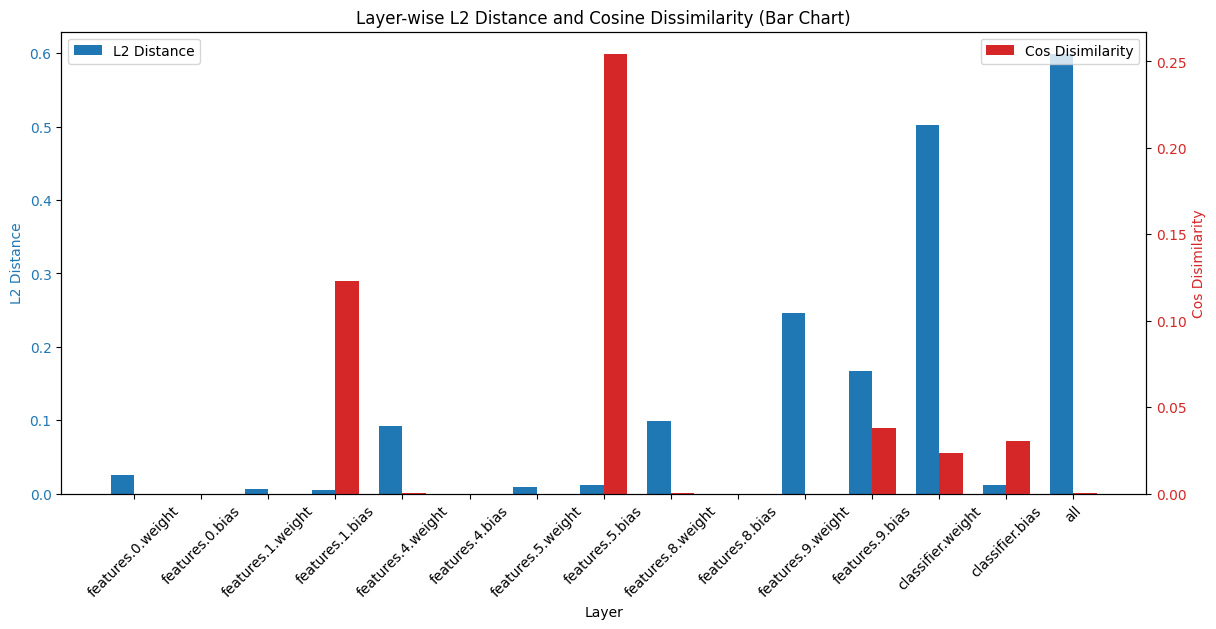

In [22]:
compare_model_weights(model1, model2)

In [28]:
def get_diff(model1, model2):
    '''get the update weight'''
    model1_sd = model1.state_dict()
    model2_sd = model2.state_dict()
    
    delta = {}
    for key, var in model1_sd.items():
        delta[key] = model1_sd[key] - model2_sd[key]
    return delta

In [52]:
def merge_w(model1_sd, model2_sd, w1=1, w2=1):
    '''get the update weight'''
    # model1_sd = model1.state_dict()
    # model2_sd = model2.state_dict()
    
    merger = {}
    for key, var in model1_sd.items():
        merger[key] = model1_sd[key] * w1 + model2_sd[key] *w2
    return merger

In [86]:
delta_fin = get_diff(model2, model1)

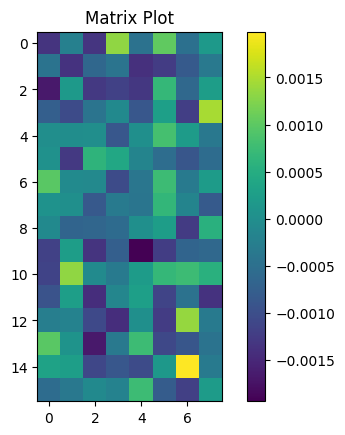

In [46]:
model1.state_dict()["features.5.bias"] 

plt.imshow(model1.state_dict()["features.5.bias"].detach().view(16,8).cpu().numpy(), cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to show the scale
plt.title('Matrix Plot')
plt.show()

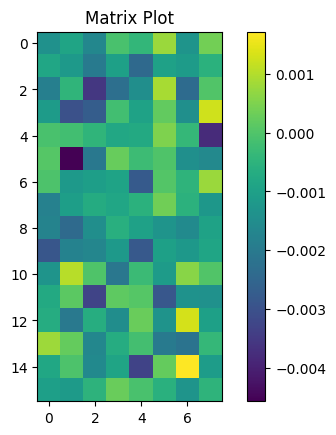

In [47]:
model2.state_dict()["features.5.bias"] 
plt.imshow(model2.state_dict()["features.5.bias"].detach().view(16,8).cpu().numpy(), cmap='viridis', interpolation='nearest')
plt.colorbar()  # Add a color bar to show the scale
plt.title('Matrix Plot')
plt.show()

## model3 training with attack with delta

In [109]:
def norm_clipping(x, C):
    """Clips the tensor x to have L2 norm at most C."""
    norm_x = torch.norm(x, p=2)  # Compute L2 norm
    factor = min(1.0, C / (norm_x + 1e-10))  # Avoid division by zero
    return x * factor

In [110]:
model3 = model_fn().to(device) # train with clean data
model3.load_state_dict(model0_sd)

optimizer3 = optim.SGD(model3.parameters(), lr=0.0001)

In [112]:
# train model1 keep logging of gradient
training_loss3, samples3 = 0.0, 0
val_loss_list3 = []
val_acc_list3 = []
val_loss_list4 = []
val_acc_list4 = []
grad_list = []
last_model = copy.deepcopy(model0)
lambda_ = 1
epochs = 6

for ep in range(epochs):
    last_model = copy.deepcopy(model3)
    # training
    for it, (x, y) in enumerate(sub_train_loader):
        x, y = x.to(device), y.to(device)
        optimizer3.zero_grad()
        loss = nn.CrossEntropyLoss()(model3(x), y)
        training_loss3 += loss.item() * y.shape[0]
        samples3 += y.shape[0]
        loss.backward()
        optimizer3.step()
    
    # validation
    val_loss, val_acc = model_validation(model3, test_loader)
    val_loss_list3.append(val_loss)
    val_acc_list3.append(val_acc)
    print(f"ep{ep}, val_loss:{val_loss}, val_acc:{val_acc}")

    # get gradient
    grad_dict_org = get_diff(model3, last_model)
    # get norm 
    grad_org_norm = torch.norm(parameters_dict_to_vector(grad_dict_org), p=2).item()
    
    print("grad_org_norm", grad_org_norm)
    
    # add attack
    # delta = get_diff(model2, model3)
    delta = delta_fin
    
    print("delta_norm", torch.norm(parameters_dict_to_vector(delta), p=2).item())
    delta_norm = norm_clipping(parameters_dict_to_vector(delta), C=grad_org_norm)
    
    # restore_dict_grad_dict
    model3_craft = restore_dict_grad_flat(delta_norm, model3.state_dict(), model3.state_dict())
    model3.load_state_dict(model3_craft)
    val_loss, val_acc = model_validation(model3, test_loader)
    val_loss_list4.append(val_loss)
    val_acc_list4.append(val_acc)
    print(f"ep{ep}, craft val_loss:{val_loss}, craft val_acc:{val_acc}")
    
    # get cos between org grad and the malicious grad
    grad_dict = get_diff(model3, last_model)
    cos_d = cos_dist(flat_dict(grad_dict), flat_dict(grad_dict_org))
    print("cos_d", cos_d)

ep0, val_loss:1.9961129685941215, val_acc:0.4882
grad_org_norm 0.039420533925294876
delta_norm 16.416234970092773
ep0, craft val_loss:1.9954490151268225, craft val_acc:0.4907
cos_d tensor(0.2913, device='cuda:0')
ep1, val_loss:1.8667577965952717, val_acc:0.5892
grad_org_norm 0.035218652337789536
delta_norm 16.416234970092773
ep1, craft val_loss:1.8662793190715412, craft val_acc:0.5917
cos_d tensor(0.2915, device='cuda:0')
ep2, val_loss:1.7587008521960565, val_acc:0.619
grad_org_norm 0.032132189720869064
delta_norm 16.416234970092773
ep2, craft val_loss:1.7583344477814988, craft val_acc:0.6195
cos_d tensor(0.2917, device='cuda:0')
ep3, val_loss:1.6671626693524493, val_acc:0.638
grad_org_norm 0.02956932783126831
delta_norm 16.416234970092773
ep3, craft val_loss:1.666884217780238, craft val_acc:0.6377
cos_d tensor(0.2917, device='cuda:0')
ep4, val_loss:1.5885603656403173, val_acc:0.6497
grad_org_norm 0.027315190061926842
delta_norm 16.416234970092773
ep4, craft val_loss:1.5883252696869092

In [101]:
x = torch.tensor([-1.0,2.0,3.0])

In [107]:
norm_clipping(x, C=4)

tensor([-1.,  2.,  3.])

In [104]:
torch.norm(x, p=2)

tensor(3.7417)